In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import datetime as dt 
import astropy 
import pytz 
import src 
import pandas as pd 
import astroplan 



c:\Users\johnm\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
c:\Users\johnm\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [40]:
# Important camera properties 

# Color camera: 
# Fov: 42' x 27.6' 
# Plate scale: 0.41" / pixel 

# Monochrome camera: 
# Fov: 32' x 21.5' 
# Plate scale: 0.63" / pixel 




# print parameters of movement of a source across the sky 
def func(pixels_per_hour=None, time_cross_FOV=None, arcsec_per_hour=None, arcsec_per_pixel=0.63, FOV_arcmin=42): 

    FOV_arcsec = FOV_arcmin*60 

    if time_cross_FOV is not None: 
        arcsec_per_hour = FOV_arcsec / time_cross_FOV
        pixels_per_hour = arcsec_per_hour / arcsec_per_pixel 
    
    if pixels_per_hour is not None: 
        arcsec_per_hour = pixels_per_hour * arcsec_per_pixel 
        time_cross_FOV = FOV_arcsec / arcsec_per_hour 

    if arcsec_per_hour is not None: 
        pixels_per_hour = arcsec_per_hour / arcsec_per_pixel 
        time_cross_FOV = FOV_arcsec / arcsec_per_hour 


    print(f"Pixels per hour: {pixels_per_hour} pix")
    print(f'Arcsec per hour: {arcsec_per_hour}"') 
    print(f"Time to cross camera: {time_cross_FOV} hours ({time_cross_FOV*60:.0f} mins)") 
    print(f"\n") 



print("Minimum speed to detect in single night")
func(pixels_per_hour=10)

print("Maximum speed (moves out of frame in less than an hour)")
func(time_cross_FOV=1) 


Minimum speed to detect in single night
Pixels per hour: 10.0 pix
Arcsec per hour: 6.3"
Time to cross camera: 400.0 hours (24000 mins)


Maximum speed (moves out of frame in less than an hour)
Pixels per hour: 4000.0 pix
Arcsec per hour: 2520.0"
Time to cross camera: 1.0 hours (60 mins)




Comets and asteroids target list (spring-summer 2026) 

| Name               | Date Observable        | Speed (arcsec/hr) | Magnitude |
|--------------------|------------------------|-------------------|-----------|
| 20 Massalia        | until July 23          | 3–60              | 9.3–11.5  |
| 7 Iris             | until July 23          | 1–54              | 9.7–11.4  |
| 19 Fortuna         | until July 23          | 2–43              | 11.5–13.2 |
| 41 Daphne          | until July 23          | 2–67              | 11.6–12.3 |
| 24P/Schaumasse     | May 14 – Aug 20        | 0–39              | 17–21 or 13? |
| C/2025 L1          | until September 17     | 1–172             | 15–19     |
| C/2022 QE78        | until July 23          | 0–291             | 15.7–16.4 |




To find asteroids and comets that will be visible, use: https://telescopius.com/ 

After choosing a target, calculate its ephemeris using: https://ssd.jpl.nasa.gov/horizons/app.html#/ 


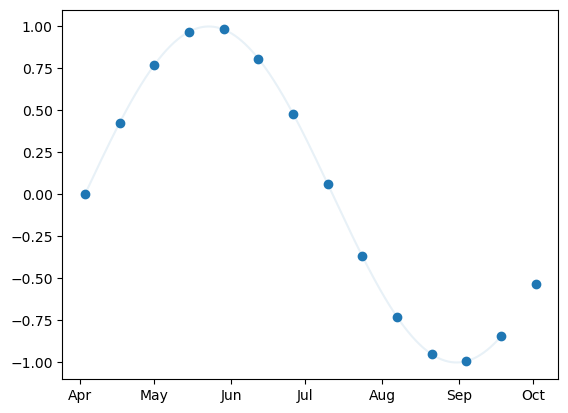

In [ ]:

# Test what different periods would look like on this cadence 


period = 200 
start_date = dt.datetime(2026, 4, 3)

x_obs = np.arange(0, 28*7, 14)
y_obs = np.sin(2*np.pi* x_obs /period) 
dates_obs = [start_date + dt.timedelta(days=float(d)) for d in x_obs]

x_smooth = np.arange(0, 24*7, 0.01)
y_smooth = np.sin(2*np.pi* x_smooth /period) 
dates_smooth = [start_date + dt.timedelta(days=float(d)) for d in x_smooth]

plt.scatter(dates_obs, y_obs) 
plt.plot(dates_smooth, y_smooth, alpha=0.1) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

